In [58]:
%cd /Users/amarmesic/Documents/tudelft/thesis/DNANet

/Users/amarmesic/Documents/tudelft/thesis/DNANet


/Users/amarmesic/miniconda3/envs/dnanet/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [59]:
from DNAnet.models.segmentation.threshold import ThresholdSegmentationModel
from DNAnet.data.data_models.custom_hid_dataset import CustomHIDDataset
from DNAnet.data.parsing.file_categorization_strategy import ProvedItFileCategorizer
from DNAnet.data.validation.sample_validation_strategy import NFIValidationStrategy
from DNAnet.data.kit_compatibility.lane_standards import InternalSizeStandard

from DNAnet.evaluation.visualizations import plot_profile


# Test Baseline Threshold Segmentation Model

This notebook demonstrates how to load a HID dataset, apply the baseline threshold segmentation model, and inspect predictions.

In [60]:
# # Create HID Dataset
# gf_panel_path = "resources/data/ProvedIt/SGPanel_Globalfiler_Panel.xml"
# hid_files_path = "/Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles"
# reference_genotype_path = "/Users/amarmesic/Documents/tudelft/thesis/DNANet/resources/data/ProvedIt/References"
# file_categorizer = ProvedItFileCategorizer()
# sample_validator = NFIValidationStrategy()
# dataset = CustomHIDDataset(
#     root_path=hid_files_path,
#     panel_path=gf_panel_path,
#     size_standard=InternalSizeStandard.GENESCAN_600_LIZ.value,
#     file_categorization_strategy=file_categorizer,
#     sample_validation_strategy=sample_validator,
# )

In [61]:
# Create HID Dataset
from config_io import load_dataset

dataset = load_dataset("provedit_data.yaml")

2025-09-02 09:57:51 INFO     Found 675 files in /Users/amarmesic/Documents/tudelft/thesis/datasets/USE THIS - PROVEDIt_2-5-Person Profiles_3500 5sec_GF29cycles


2025-09-02 09:57:52 WARNING  Size standard for E04_RD14-0003-33_34-1,2-M4d-0.045GF-Q1.3_05.5sec.hid differs 18.912544484957948 from the expected 
2025-09-02 09:57:54 WARNING  Size standard for H08_RD14-0003-49_50_29-1,4,1-M2e-0.378GF-Q1.4_08.5sec.hid differs 13.401428160223645 from the expected 
2025-09-02 09:57:54 WARNING  Size standard for G03_RD14-0003-40_41-1,4-M3e-0.625GF-Q0.8_07.5sec.hid differs 12.982847650856456 from the expected 
2025-09-02 09:57:56 WARNING  Size standard for E03_RD14-0003-48_49_50_29-1,4,4,4-M2I15-0.75GF-Q1.1_05.5sec.hid differs 13.001695302289932 from the expected 
2025-09-02 09:57:57 WARNING  Size standard for E05_RD14-0003-46_47_48-1,1,1-M3I35-0.189GF-QLAND_05.5sec.hid differs 18.824515396807158 from the expected 
2025-09-02 09:58:02 INFO     Number of valid images: 670
2025-09-02 09:58:02 INFO     Limiting dataset to 3
2025-09-02 09:58:02 INFO     Number of files limited to: 3


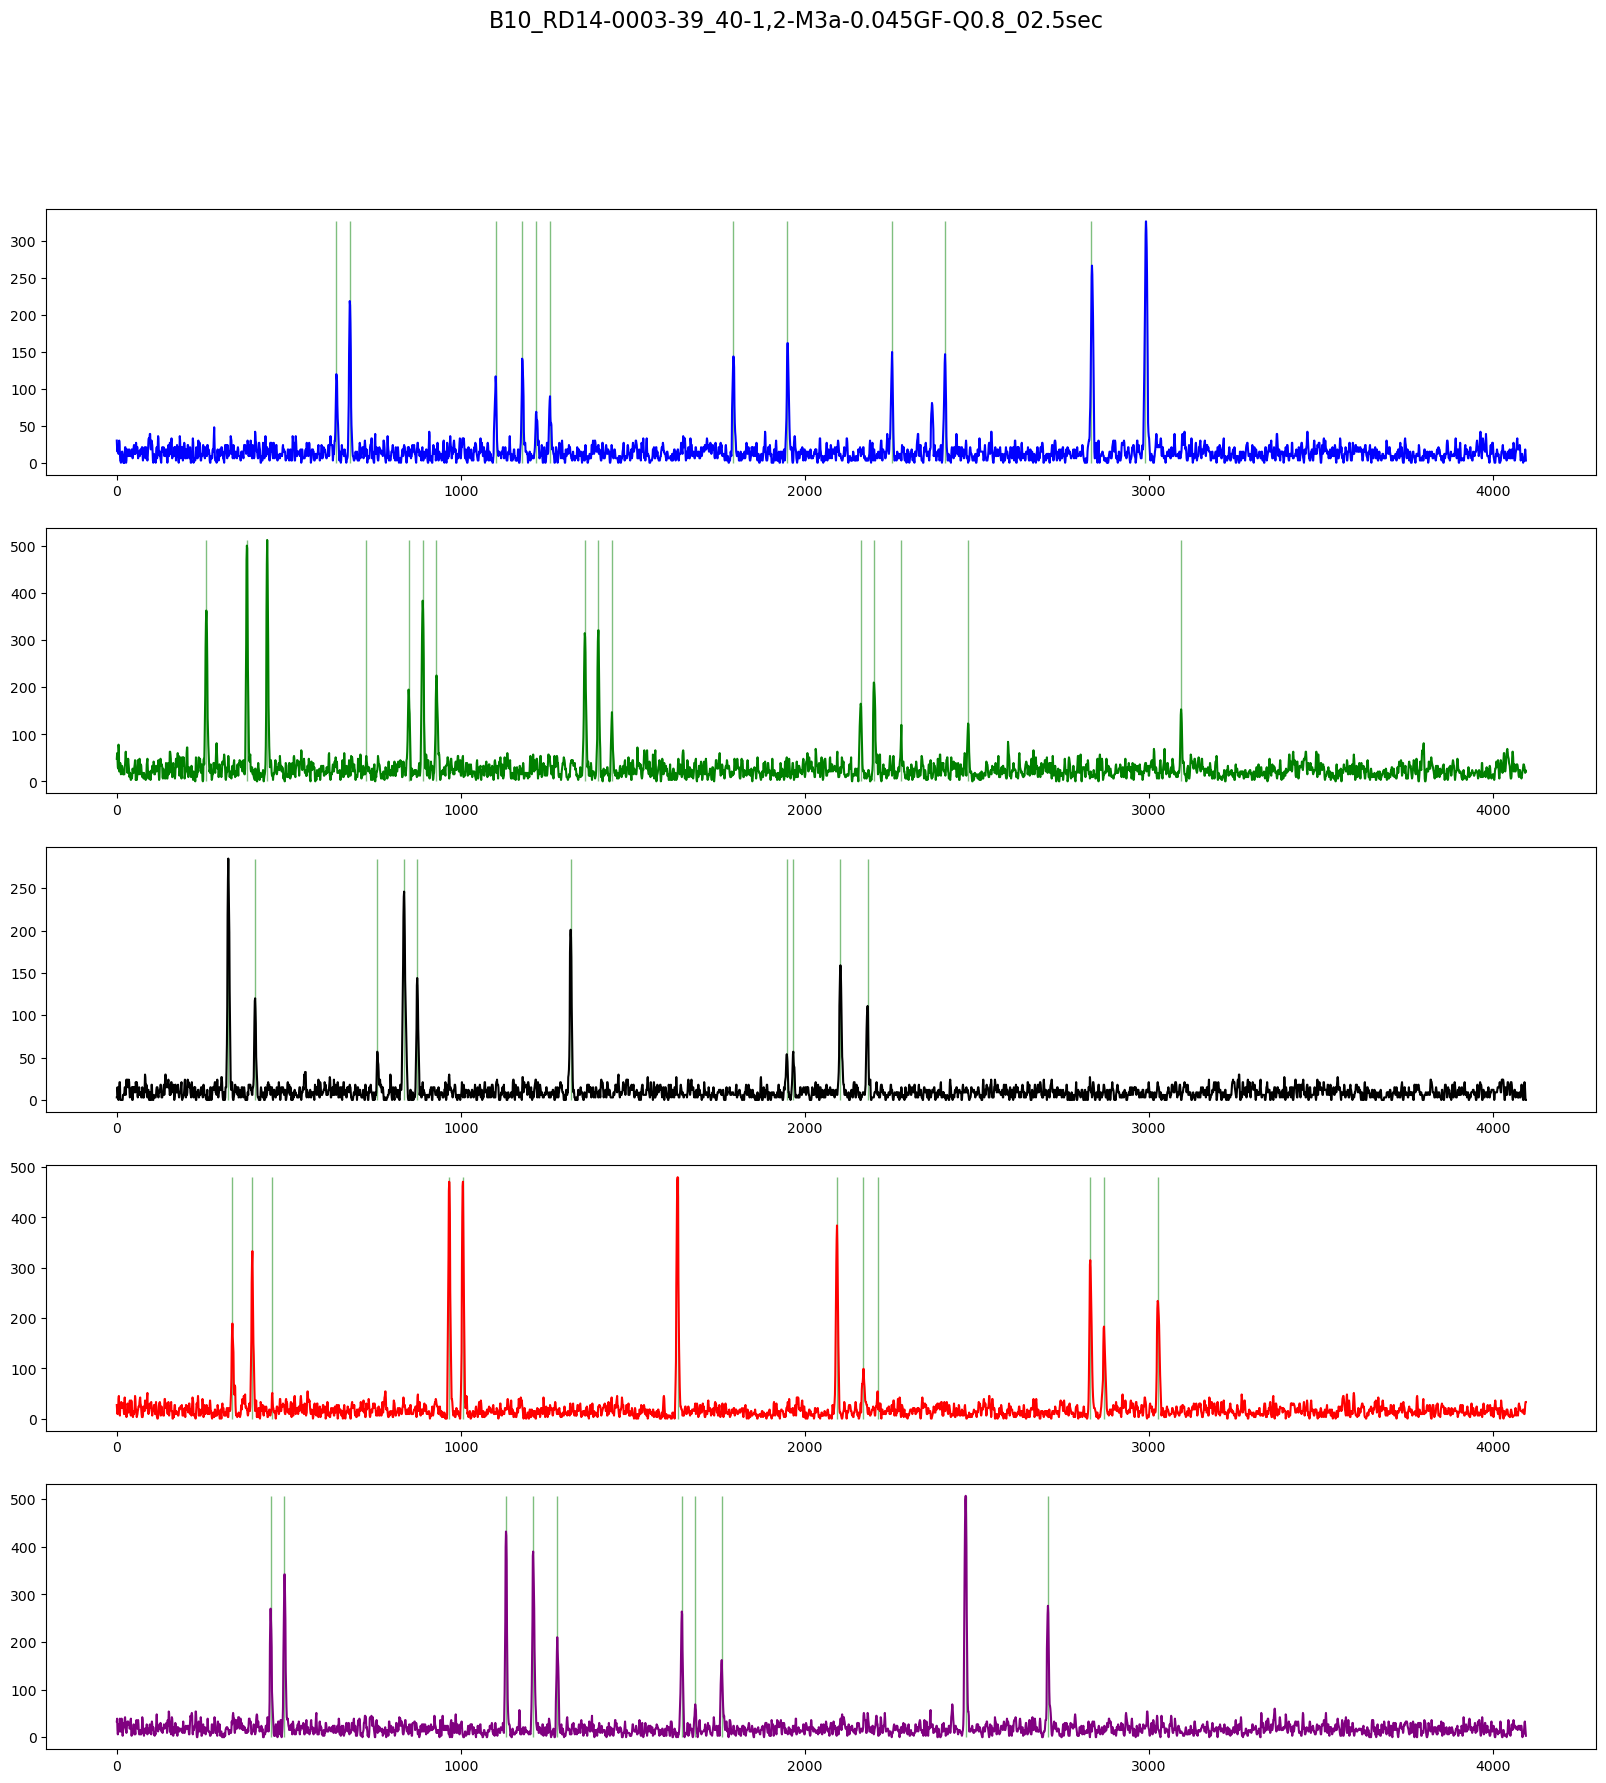

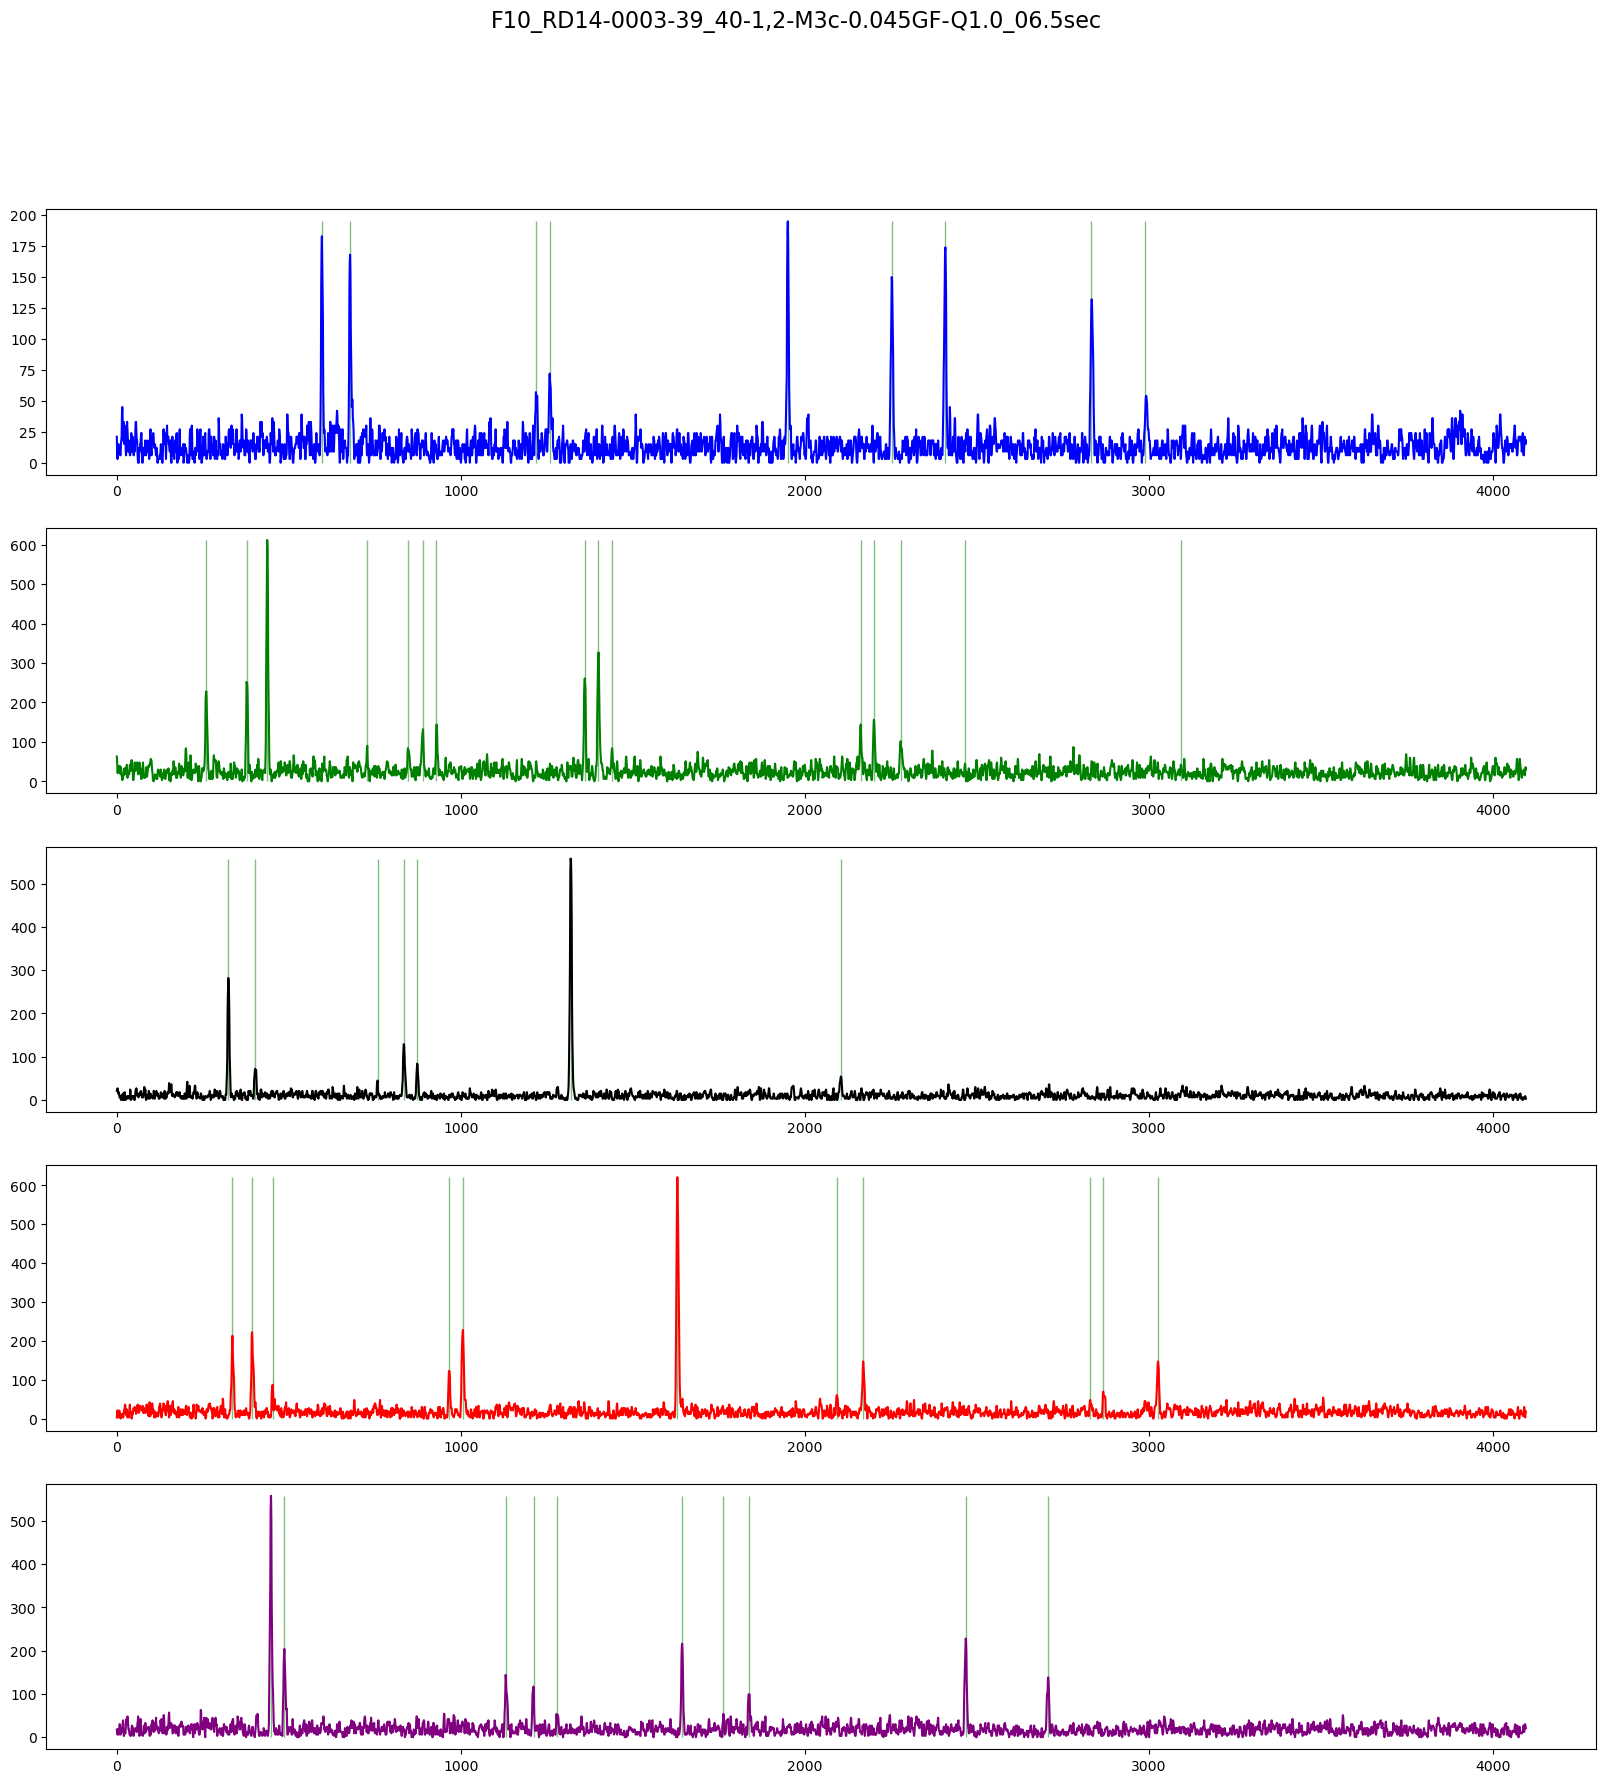

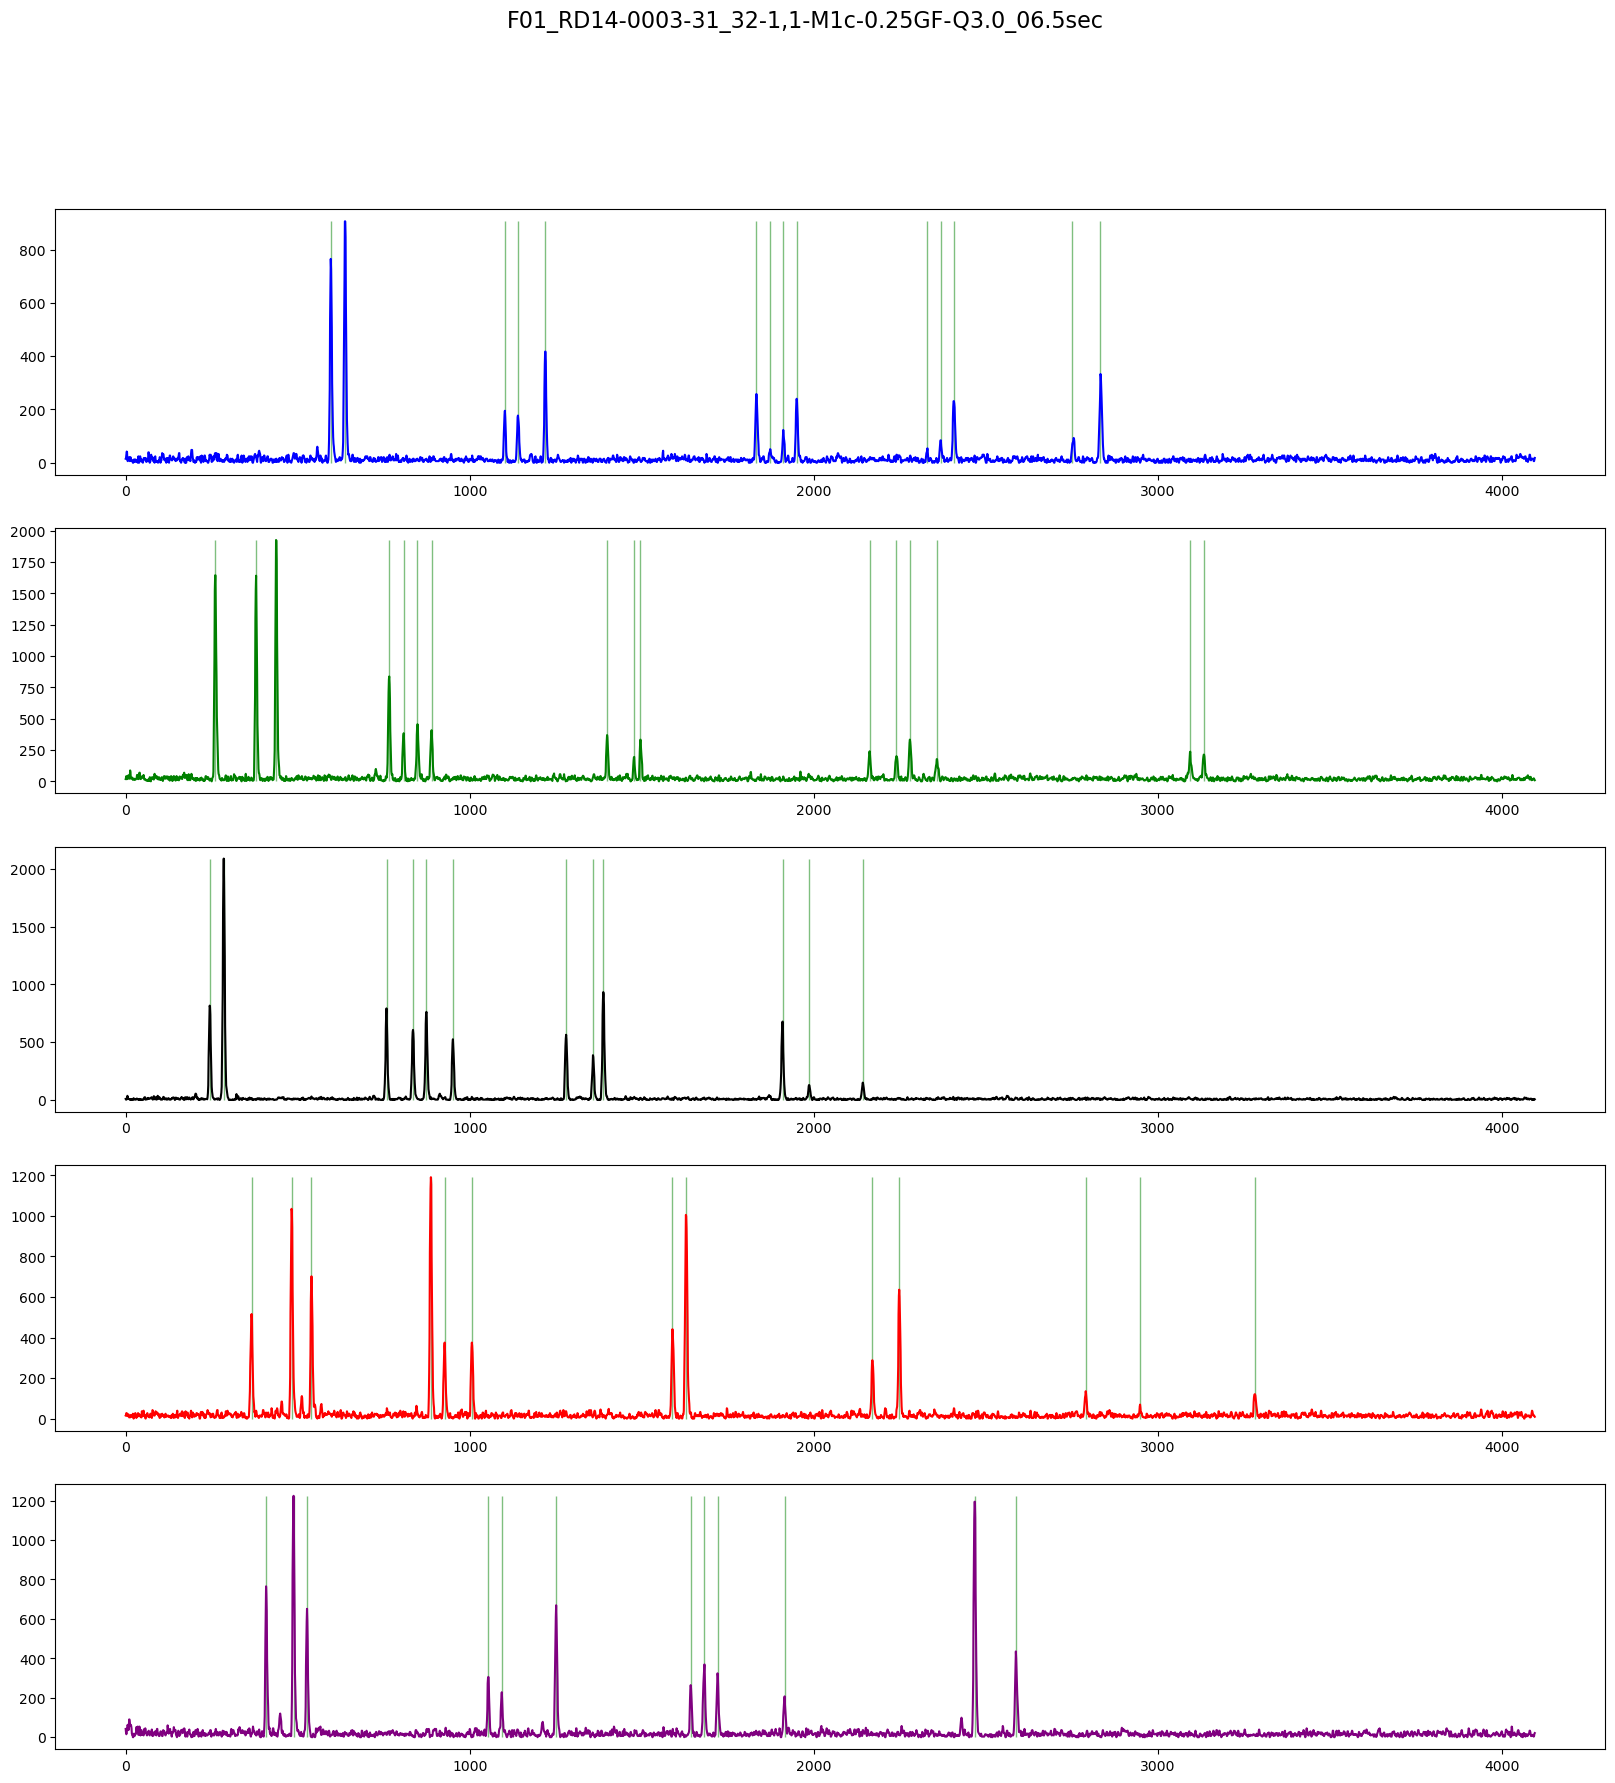

In [62]:
plot_profile(dataset, prediction_as_mask=False)

In [63]:
# Initialize the baseline thresholding model
model = ThresholdSegmentationModel(threshold=75, apply_allele_caller=True)

# make a list of predictions
# predictions = [model.predict(image) for image in dataset]
predictions = model.predict_batch(dataset)

# Print shapes of the dataset and predictions
dataset[0].data.shape, predictions[0].image.shape

((5, 4096, 1), (5, 4096, 1))

In [64]:
from DNAnet.evaluation.segmentation.allele_metrics import allele_f1_score, allele_precision, allele_recall
from DNAnet.evaluation.segmentation.pixel_metrics import pixel_f1_score, pixel_precision, pixel_recall

f1 = pixel_f1_score(dataset, predictions)
precision = pixel_precision(dataset, predictions)
recall = pixel_recall(dataset, predictions)
print(f"- Pixel F1 Score: {f1:.4g}")
print(f"- Pixel Precision: {precision:.4g}")
print(f"- Pixel Recall: {recall:.4g}")

alelle_f1 = allele_f1_score(dataset, predictions)
print(f'- Allele F1 Score: {alelle_f1:.4g}')
print(f'- Allele Precision: {allele_precision(dataset, predictions):.4g}')
print(f'- Allele Recall: {allele_recall(dataset, predictions):.4g}')

- Pixel F1 Score: 0.1882
- Pixel Precision: 0.1058
- Pixel Recall: 0.8539
- Allele F1 Score: 0.7612
- Allele Precision: 0.843
- Allele Recall: 0.6938


## Tracking Performance of different thresholds

### 70 - Best Pixel F1
- Pixel F1 Score: 0.5741
- Pixel Precision: 0.5376
- Pixel Recall: 0.6159
- Allele F1 Score: 0.771
- Allele Precision: 0.7618
- Allele Recall: 0.7805

### 75 - Best Allele F1
- Pixel F1 Score: 0.5735
- Pixel Precision: 0.5425
- Pixel Recall: 0.6082
- Allele F1 Score: 0.7738
- Allele Precision: 0.7726
- Allele Recall: 0.7749

### 100
- Pixel F1 Score: 0.561
- Pixel Precision: 0.5737
- Pixel Recall: 0.5488
- Allele F1 Score: 0.7699
- Allele Precision: 0.8186
- Allele Recall: 0.7267

## Visualize Example Prediction

Let's visualize the segmentation mask for the first image in the dataset.

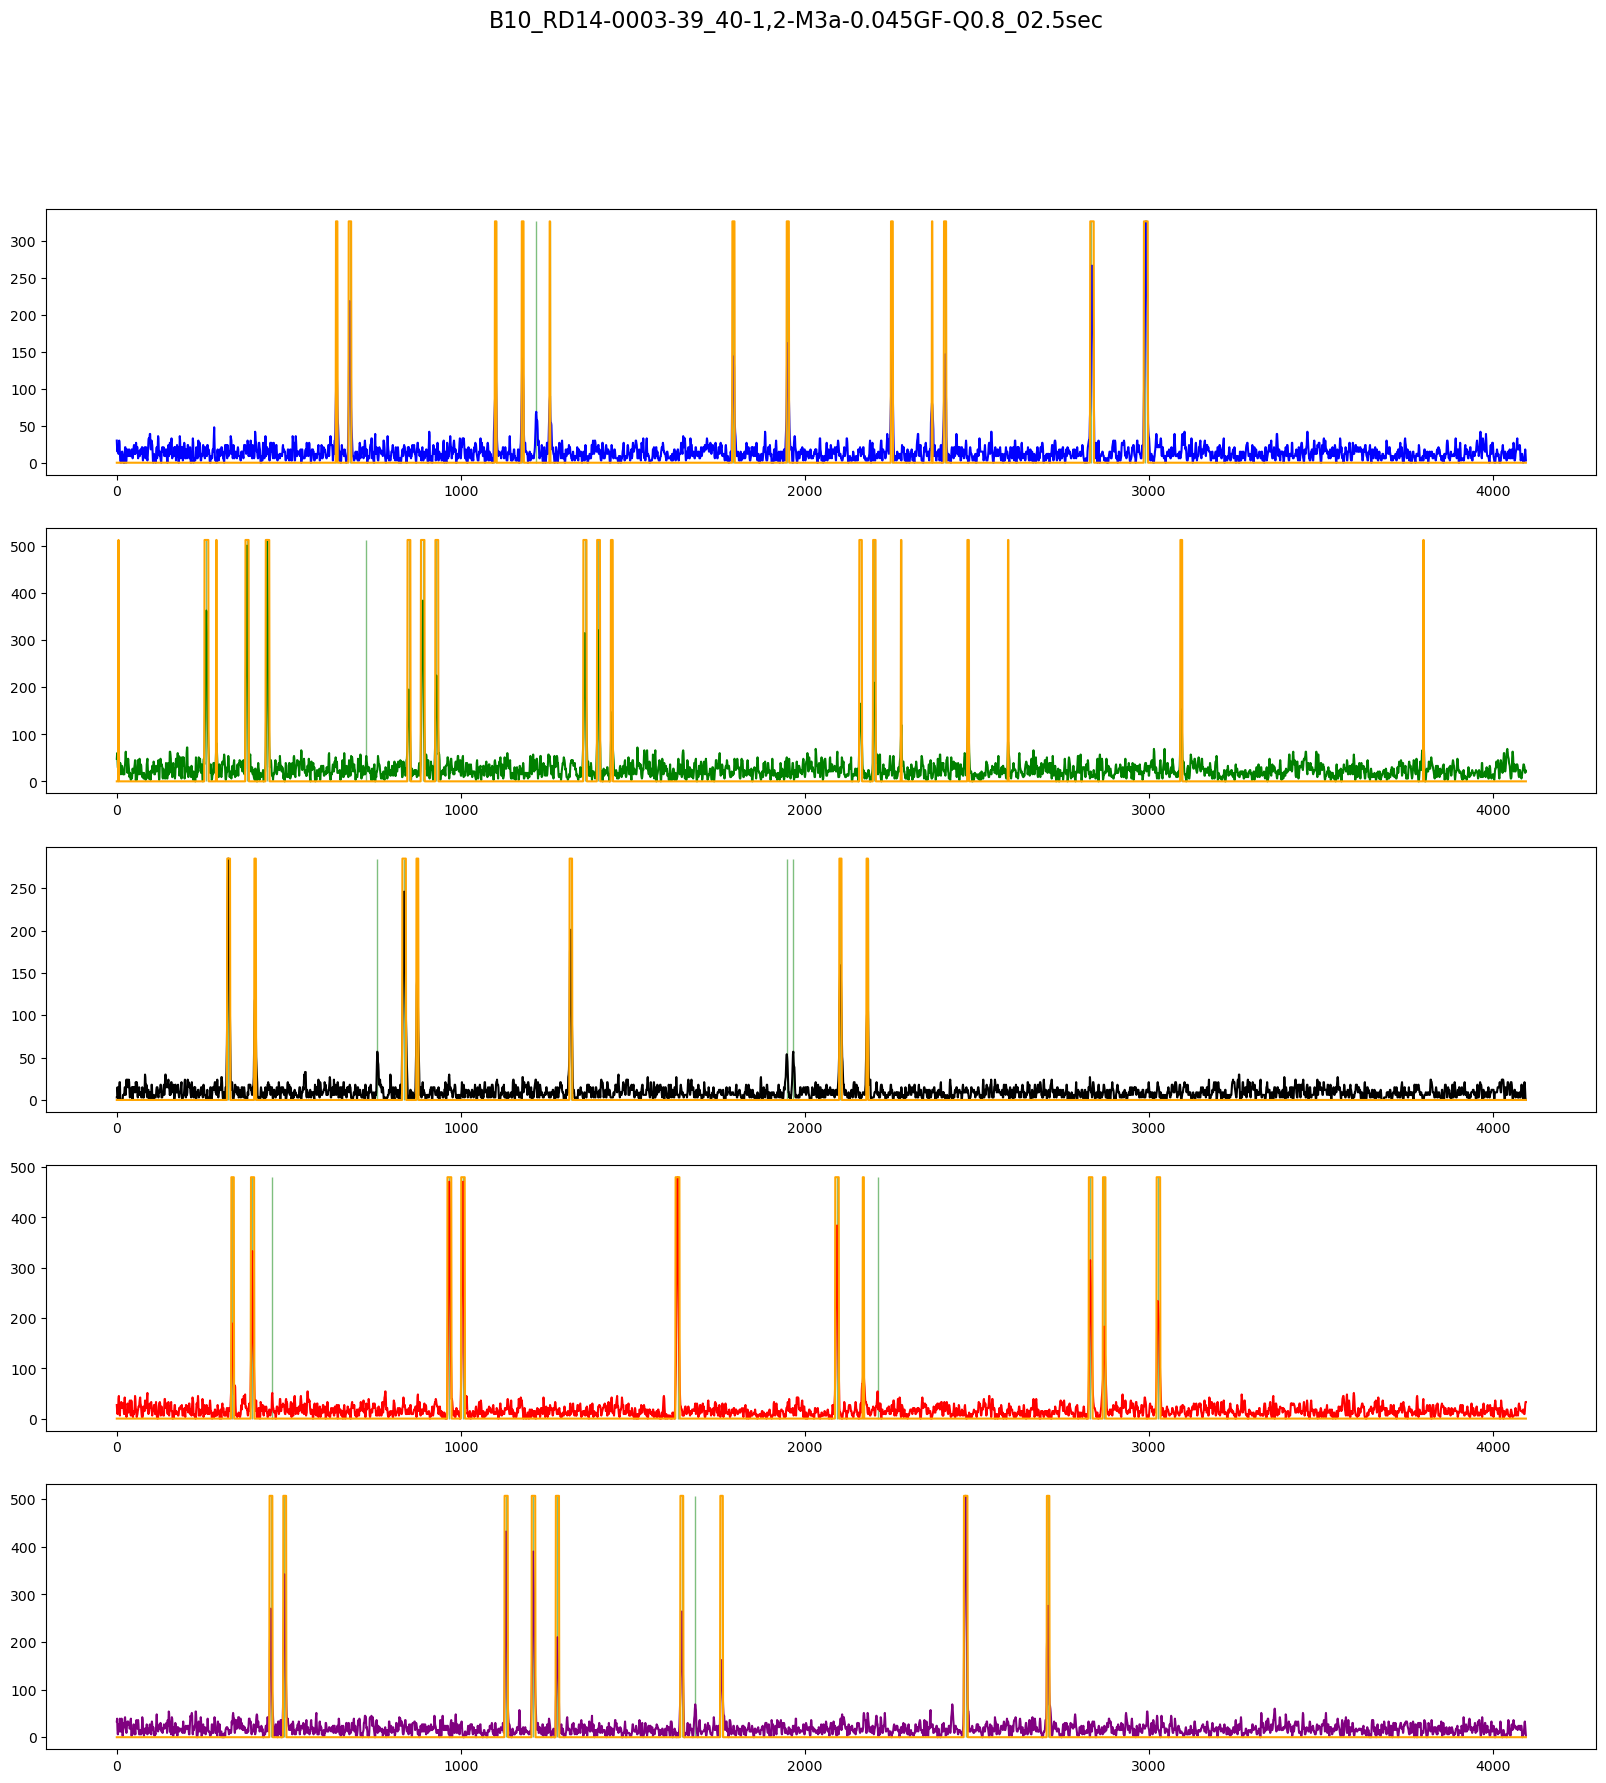

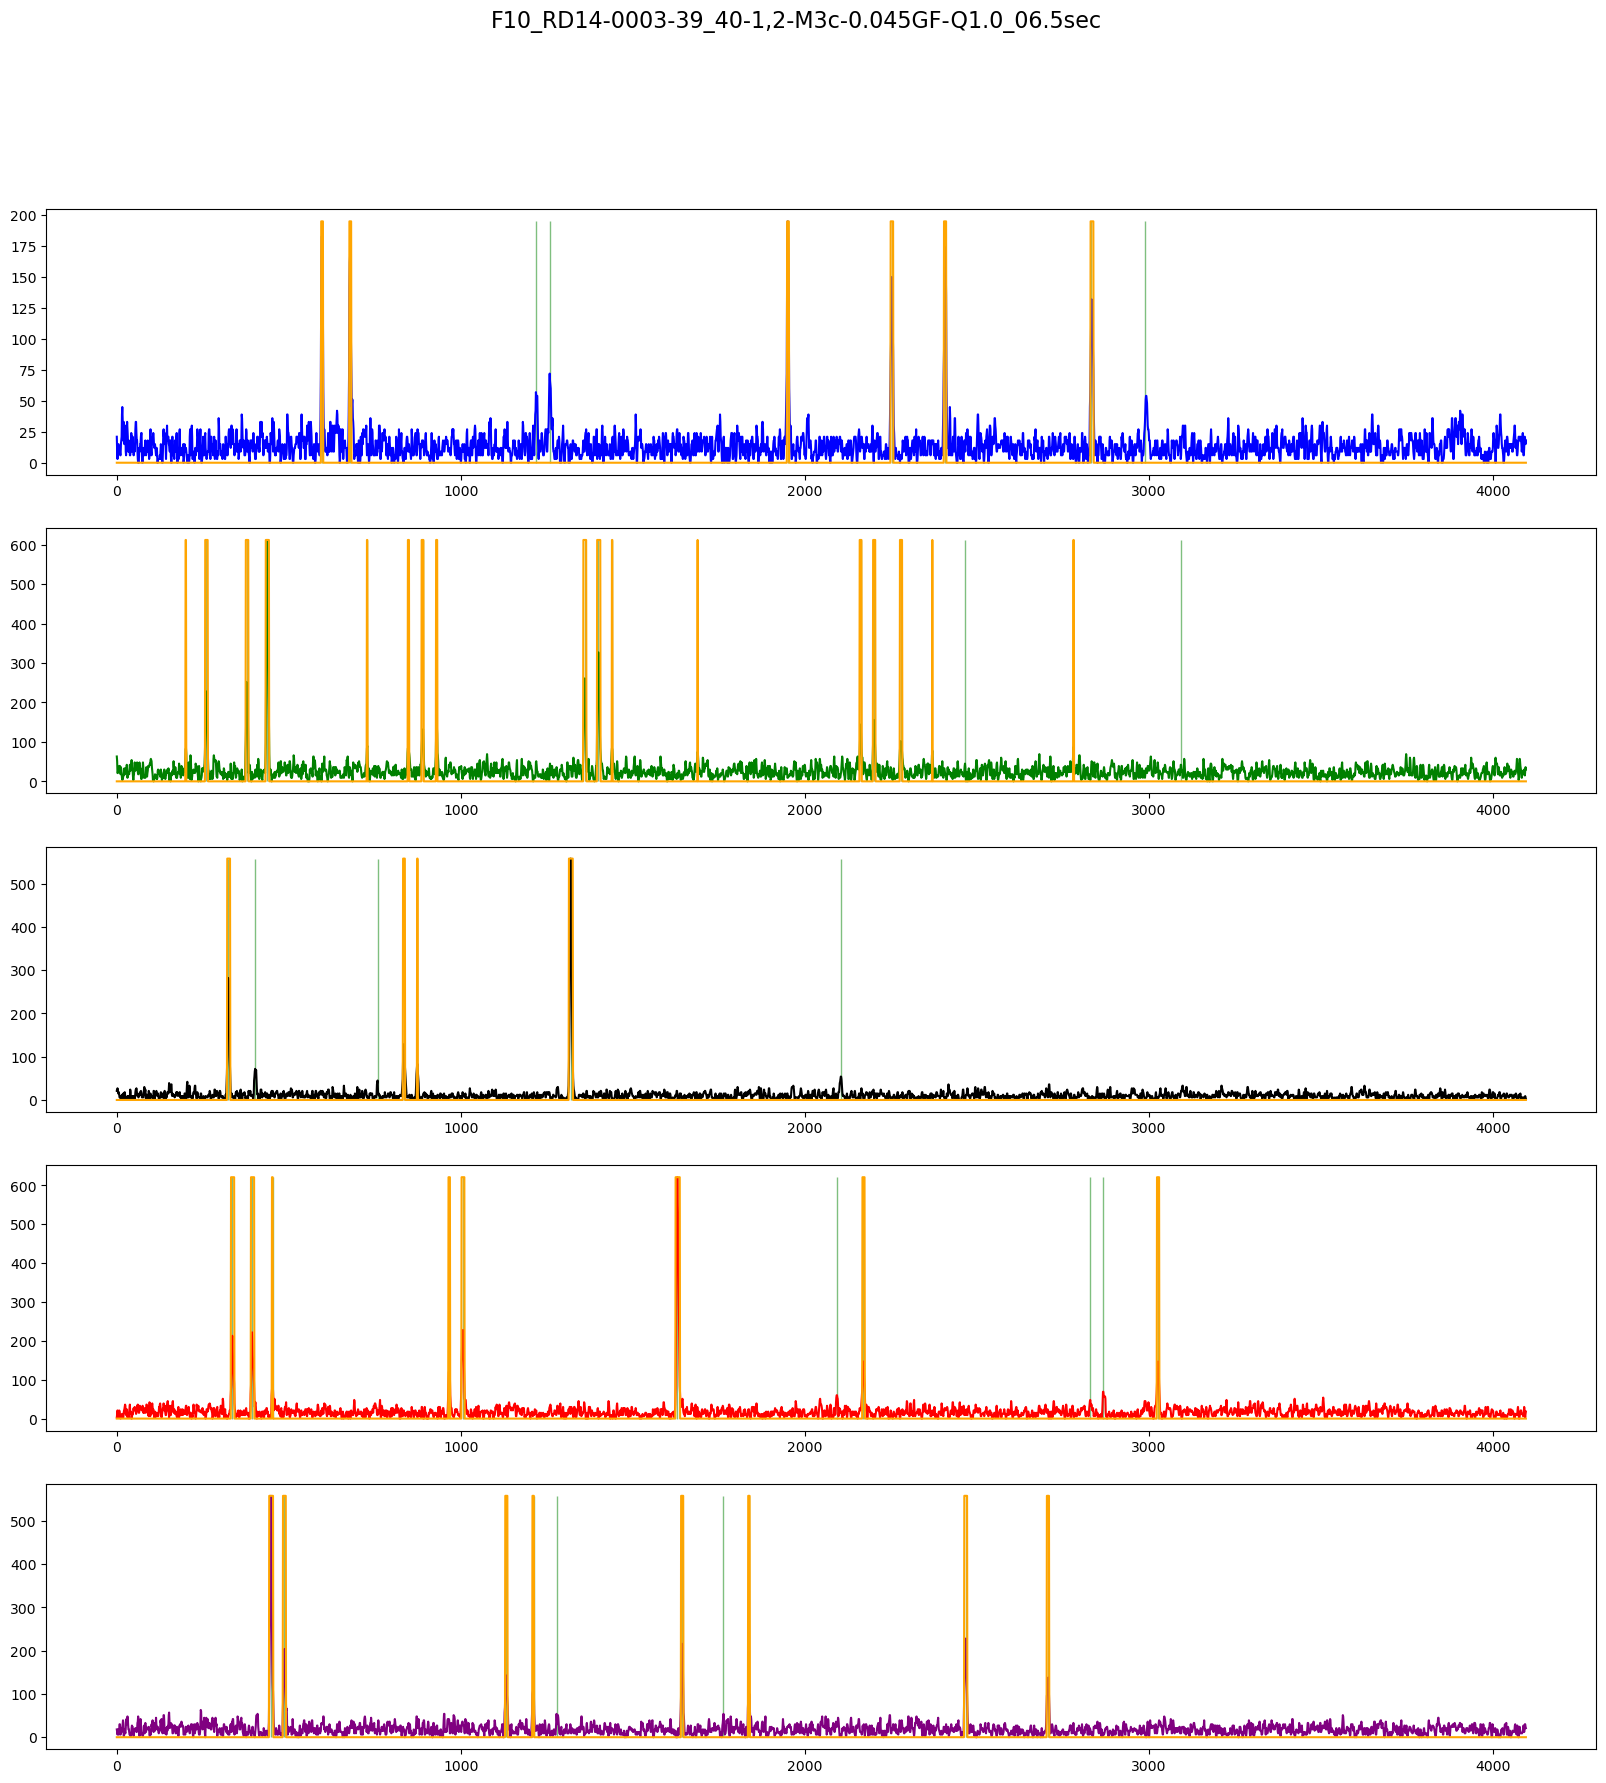

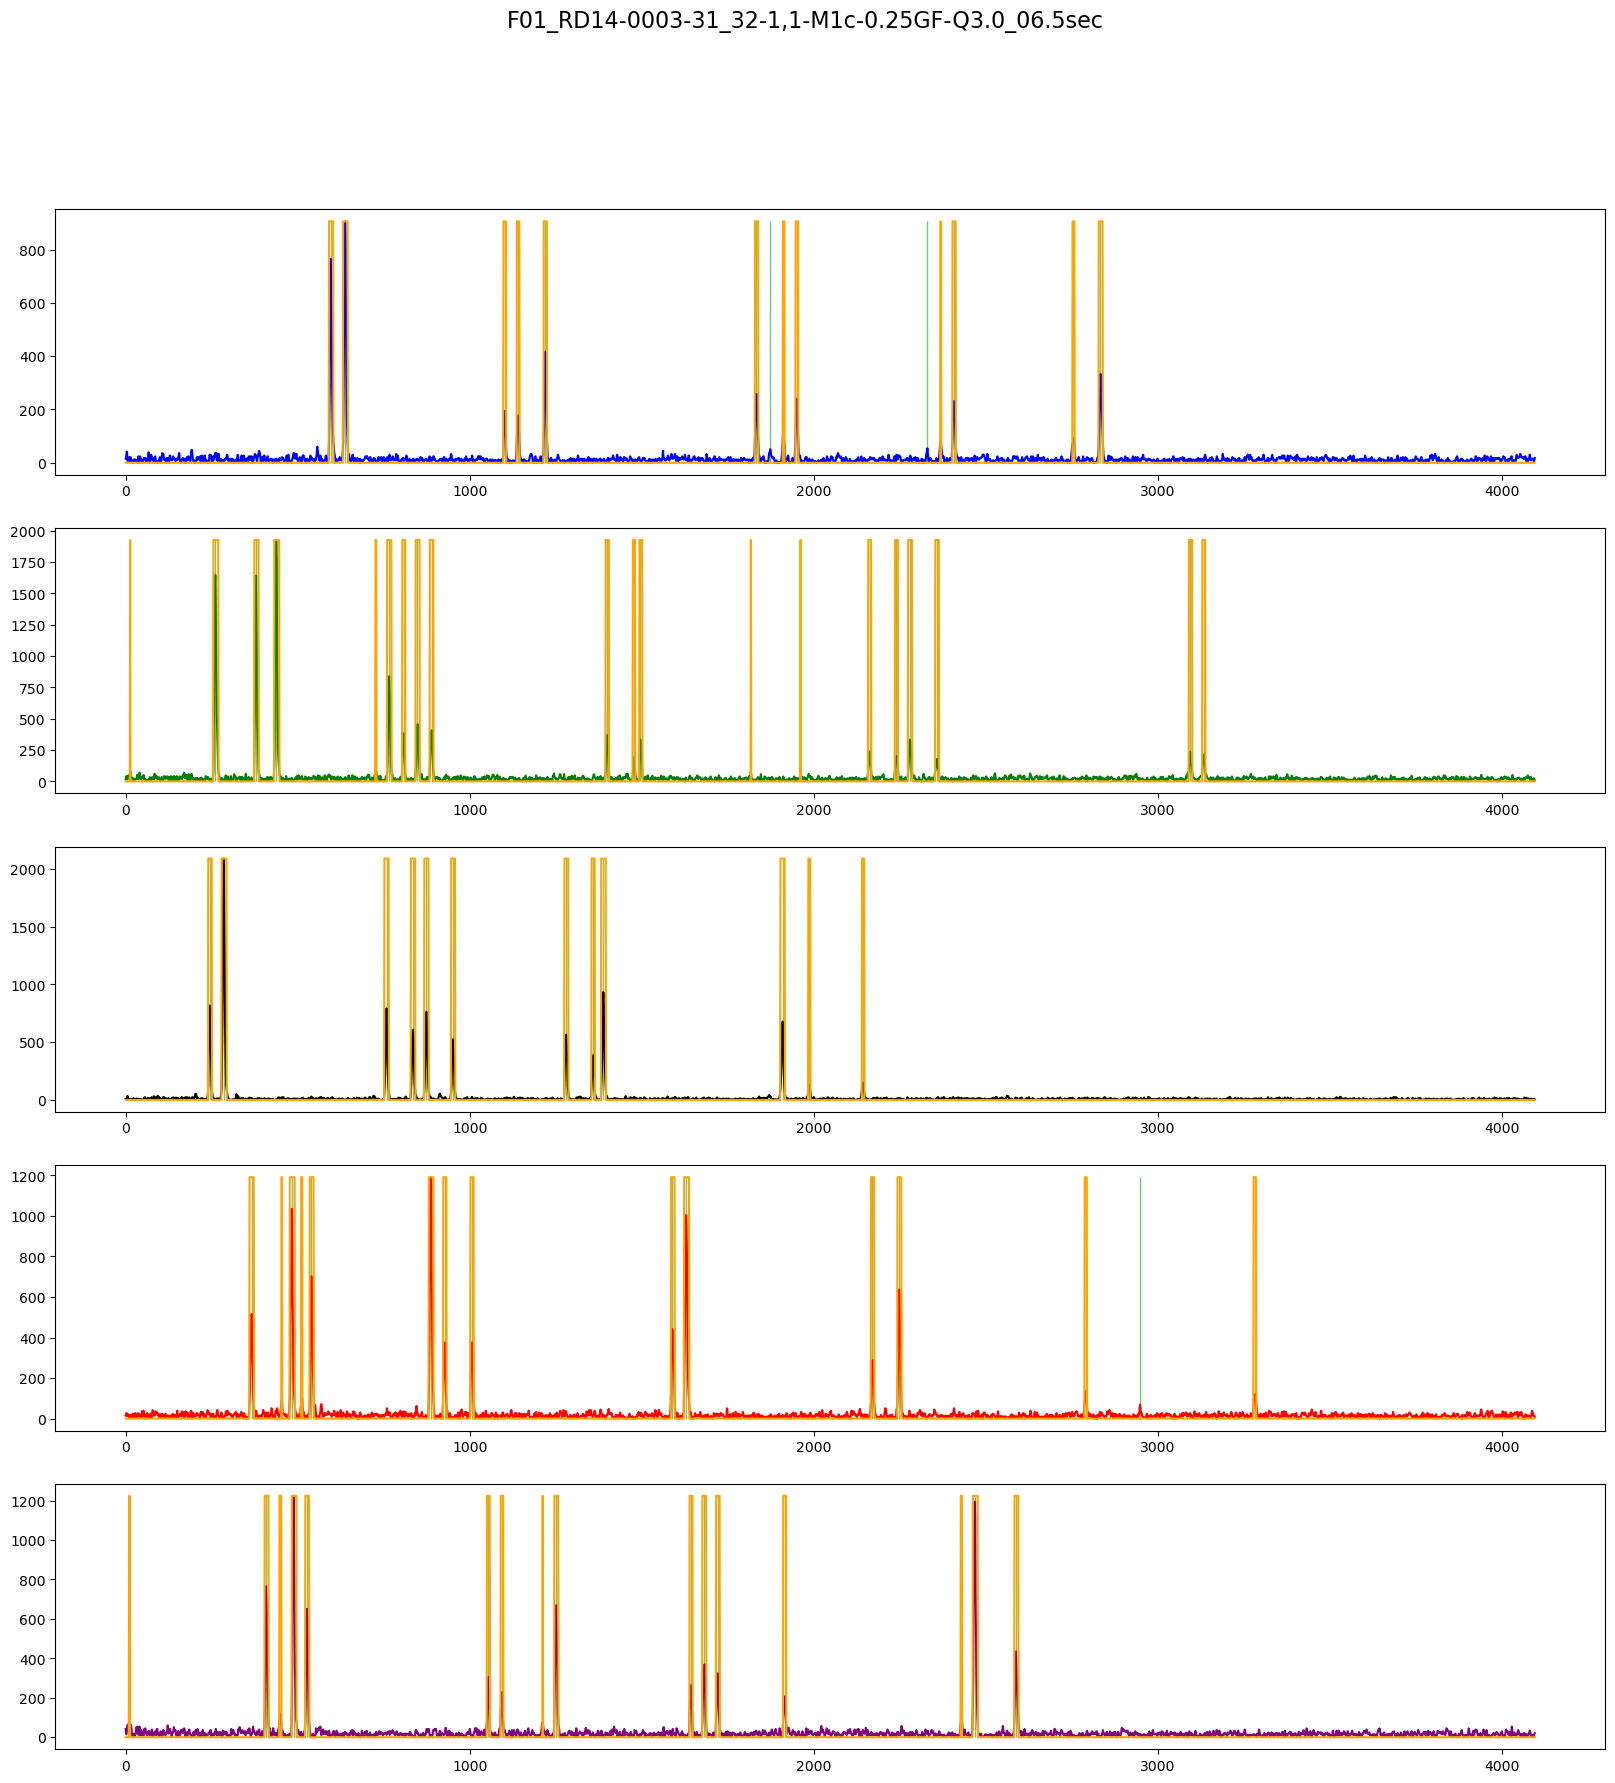

In [65]:
plot_profile(dataset, predictions, prediction_as_mask=False)

In [66]:
# import neptune
# run = neptune.init_run(
#     name="基线-75rfu-134+长-1正真:_正假-预：缩放-第3",
#     project="amar-mesic/dna-thesis",
#     api_token="eyJhcGlfYWRkcmVzcyI6Imh0dHBzOi8vYXBwLm5lcHR1bmUuYWkiLCJhcGlfdXJsIjoiaHR0cHM6Ly9hcHAubmVwdHVuZS5haSIsImFwaV9rZXkiOiJkOTQ1Njc4MC0yOTcyLTRlMmQtYTMwMy0xOGYxZTAwMmIzZGUifQ==",
# )

# run["test/pixel_f1"] = float(f"{f1:.4g}")
# run["test/pixel_precision"] = float(f"{precision:.4g}")
# run["test/pixel_recall"] = float(f"{recall:.4g}")
# run["test/allele_f1"] = float(f"{alelle_f1:.4g}")
# run["test/allele_precision"] = float(f"{allele_precision(dataset, predictions):.4g}")
# run["test/allele_recall"] = float(f"{allele_recall(dataset, predictions):.4g}")
# run.stop()